In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, gc
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/EDA_Project'
print('Data directory:', DATA_DIR)
print('Files:', os.listdir(DATA_DIR))

Mounted at /content/drive
Data directory: /content/drive/MyDrive/EDA_Project
Files: ['branch_region_economy.csv', 'collateral_assets.csv', 'credit_card_behavior.csv', 'customer_bureau.csv', 'FinSight_Exam_Paper.docx', 'loan_enquiry_bureau.csv', 'loan_performance.csv', 'loans_master.csv', 'monthly_emi_track.csv', 'payment_history.csv', 'loans.parquet', 'customer_bureau.parquet', 'payment_history.parquet', 'loan_performance.parquet', 'loan_enquiry_bureau.parquet', 'credit_card_behavior.parquet', 'collateral_assets.parquet', 'branch_region_economy.parquet', 'monthly_emi_track.parquet', 'finsight_merged.parquet']


In [ ]:
Q1 A


In [ ]:
import os
import pandas as pd

def downcast_df(df):
    """Downcast numeric columns to reduce memory."""
    for col in df.select_dtypes(include='integer').columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    for col in df.select_dtypes(include='float').columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    return df


CSV_FILES = [
    'branch_region_economy.csv',
    'collateral_assets.csv',
    'credit_card_behavior.csv',
    'customer_bureau.csv',
    'loan_enquiry_bureau.csv',
    'loan_performance.csv',
    'loans_master.csv',
    'monthly_emi_track.csv',
    'payment_history.csv'
]

dfs = {}
mem_report = []

RAM_THRESHOLD_MB = 400
CHUNK_SIZE = 200_000

for fname in CSV_FILES:
    fpath = os.path.join(DATA_DIR, fname)
    file_size_mb = os.path.getsize(fpath) / 1e6

    print(f"Loading {fname} ({file_size_mb:.1f} MB)...")

    if file_size_mb > RAM_THRESHOLD_MB:
        chunks = []
        before_mem_total = 0
        after_mem_total = 0

        for chunk in pd.read_csv(fpath, chunksize=CHUNK_SIZE):
            before_mem_total += chunk.memory_usage(deep=True).sum() / 1e6

            chunk = downcast_df(chunk)
            after_mem_total += chunk.memory_usage(deep=True).sum() / 1e6

            chunks.append(chunk)

        df_tmp = pd.concat(chunks, ignore_index=True)

    else:
        df_tmp = pd.read_csv(fpath)

        before_mem_total = df_tmp.memory_usage(deep=True).sum() / 1e6

        df_tmp = downcast_df(df_tmp)

        after_mem_total = df_tmp.memory_usage(deep=True).sum() / 1e6

    dfs[fname] = df_tmp

    mem_report.append({
        "File": fname,
        "Rows": df_tmp.shape[0],
        "Columns": df_tmp.shape[1],
        "Memory Before Downcast (MB)": round(before_mem_total, 2),
        "Memory After Downcast (MB)": round(after_mem_total, 2),
        "Reduction (%)": round((1 - after_mem_total / before_mem_total) * 100, 2)
    })

    print(
        f"Shape: {df_tmp.shape}, "
        f"Before: {before_mem_total:.1f} MB, "
        f"After: {after_mem_total:.1f} MB"
    )

print("All files loaded successfully.")

Loading branch_region_economy.csv (203.5 MB)...
Shape: (2000000, 19), Before: 696.4 MB, After: 540.4 MB
Loading collateral_assets.csv (179.5 MB)...
Shape: (2000000, 20), Before: 885.5 MB, After: 771.5 MB
Loading credit_card_behavior.csv (173.3 MB)...
Shape: (2000000, 17), Before: 615.7 MB, After: 481.7 MB
Loading customer_bureau.csv (324.3 MB)...
Shape: (2000000, 30), Before: 1063.4 MB, After: 875.4 MB
Loading loan_enquiry_bureau.csv (249.5 MB)...
Shape: (2000000, 24), Before: 1163.1 MB, After: 963.1 MB
Loading loan_performance.csv (133.0 MB)...
Shape: (2000000, 12), Before: 585.4 MB, After: 535.4 MB
Loading loans_master.csv (322.7 MB)...
Shape: (2000000, 27), Before: 1640.7 MB, After: 1520.7 MB
Loading monthly_emi_track.csv (243.7 MB)...
Shape: (2000000, 23), Before: 847.4 MB, After: 717.4 MB
Loading payment_history.csv (190.4 MB)...
Shape: (2000000, 18), Before: 392.0 MB, After: 314.0 MB
All files loaded successfully.


In [ ]:
memory_report_df = pd.DataFrame(mem_report)
memory_report_df

,File,Rows,Columns,Memory Before Downcast (MB),Memory After Downcast (MB),Reduction (%)
0,branch_region_economy.csv,2000000,19,696.39,540.39,22.40
1,collateral_assets.csv,2000000,20,885.53,771.53,12.87
2,credit_card_behavior.csv,2000000,17,615.65,481.65,21.77
3,customer_bureau.csv,2000000,30,1063.35,875.35,17.68
4,loan_enquiry_bureau.csv,2000000,24,1163.11,963.11,17.20
5,loan_performance.csv,2000000,12,585.41,535.41,8.54
6,loans_master.csv,2000000,27,1640.74,1520.74,7.31
7,monthly_emi_track.csv,2000000,23,847.43,717.43,15.34
8,payment_history.csv,2000000,18,392.00,314.00,19.90


In [ ]:
parquet_report = []

for fname, df in dfs.items():
    parquet_name = fname.replace(".csv", ".parquet")
    parquet_path = os.path.join(DATA_DIR, parquet_name)

    df.to_parquet(parquet_path, index=False)

    parquet_size_mb = os.path.getsize(parquet_path) / 1e6

    parquet_report.append({
        "Parquet File": parquet_name,
        "Size (MB)": round(parquet_size_mb, 2)
    })

parquet_report_df = pd.DataFrame(parquet_report)
parquet_report_df

,Parquet File,Size (MB)
0,branch_region_economy.parquet,47.71
1,collateral_assets.parquet,32.22
2,credit_card_behavior.parquet,47.20
3,customer_bureau.parquet,108.26
4,loan_enquiry_bureau.parquet,42.92
5,loan_performance.parquet,25.53
6,loans_master.parquet,67.33
7,monthly_emi_track.parquet,78.68
8,payment_history.parquet,76.55


In [ ]:
A1 B

In [ ]:
TARGET_ROWS = 2_000_000

# Start with loans_master as base
df = dfs['loans_master.csv'].copy()
print(f'Base (loans_master): {len(df):,} rows')

join_order = [
    ('customer_bureau.csv',       'loan_id'),
    ('payment_history.csv',       'loan_id'),
    ('loan_performance.csv',      'loan_id'),
    ('monthly_emi_track.csv',     'loan_id'),
    ('loan_enquiry_bureau.csv',   'loan_id'),
    ('collateral_assets.csv',     'loan_id'),
    ('credit_card_behavior.csv',  'loan_id'),
    ('branch_region_economy.csv', 'loan_id'),
]

orphan_report = []
for fname, key in join_order:
    right = dfs[fname]

    # Detect orphan records: rows in right NOT in left
    orphans = right[~right[key].isin(df[key])]
    orphan_report.append({'Table': fname, 'Orphan Rows': len(orphans)})

    # Merge
    # Drop duplicate columns (keep from left) before merge to avoid _x/_y
    overlap_cols = [c for c in right.columns if c in df.columns and c != key]
    right_clean = right.drop(columns=overlap_cols)

    df = df.merge(right_clean, on=key, how='left')

    # Assert row count
    assert len(df) == TARGET_ROWS, f'Row count mismatch after joining {fname}: {len(df)}'
    print(f'  ✓ After joining {fname}: {len(df):,} rows (assertion passed)')

print(f'\nFinal merged shape: {df.shape}')
print('\nOrphan Record Report:')
pd.DataFrame(orphan_report)

Base (loans_master): 2,000,000 rows
  ✓ After joining customer_bureau.csv: 2,000,000 rows (assertion passed)
  ✓ After joining payment_history.csv: 2,000,000 rows (assertion passed)
  ✓ After joining loan_performance.csv: 2,000,000 rows (assertion passed)
  ✓ After joining monthly_emi_track.csv: 2,000,000 rows (assertion passed)
  ✓ After joining loan_enquiry_bureau.csv: 2,000,000 rows (assertion passed)
  ✓ After joining collateral_assets.csv: 2,000,000 rows (assertion passed)
  ✓ After joining credit_card_behavior.csv: 2,000,000 rows (assertion passed)
  ✓ After joining branch_region_economy.csv: 2,000,000 rows (assertion passed)

Final merged shape: (2000000, 182)

Orphan Record Report:


,Table,Orphan Rows
0,customer_bureau.csv,0
1,payment_history.csv,0
2,loan_performance.csv,0
3,monthly_emi_track.csv,0
4,loan_enquiry_bureau.csv,0
5,collateral_assets.csv,0
6,credit_card_behavior.csv,0
7,branch_region_economy.csv,0


In [ ]:
print("""
Orphan records are loan_ids that exist in a satellite table but have NO
matching record in the base (loans_master) table. If found, they indicate
data integrity issues — e.g., records loaded out of order, deletions not
propagated across tables, or ETL pipeline failures. A left merge silently
discards them, so they must be explicitly detected and flagged.
""")

# Save to Parquet after successful join
PARQUET_PATH = '/content/drive/MyDrive/EDA_Project/finsight_merged.parquet'
df.to_parquet(PARQUET_PATH, index=False, compression='snappy')
pq_size_mb = os.path.getsize(PARQUET_PATH) / 1e6
print(f'Parquet saved → {PARQUET_PATH}')
print(f'Parquet file size: {pq_size_mb:.1f} MB')


Orphan records are loan_ids that exist in a satellite table but have NO
matching record in the base (loans_master) table. If found, they indicate
data integrity issues — e.g., records loaded out of order, deletions not
propagated across tables, or ETL pipeline failures. A left merge silently
discards them, so they must be explicitly detected and flagged.

Parquet saved → /content/drive/MyDrive/EDA_Project/finsight_merged.parquet
Parquet file size: 445.3 MB


In [ ]:
Q1 C

In [ ]:
import numpy as np
import pandas as pd

# create dirty flag
df['dirty_flag'] = 0
dirty_log = []

def mark_dirty(issue_no, column, mask, reason, strategy):
    global df

    count = mask.sum()
    print(f"Issue {issue_no} - {column}: {count:,} dirty rows")

    df.loc[mask, 'dirty_flag'] = 1
    df.loc[mask, column] = np.nan

    # median imputation
    df[column] = df[column].fillna(df[column].median())

    dirty_log.append({
        "Issue No": issue_no,
        "Column": column,
        "Approx Count": int(count),
        "Why Invalid": reason,
        "Imputation Strategy": strategy
    })


# Issue 1: Negative interest rate
mask = df['int_rate_pct'] < 0
mark_dirty(
    1,
    'int_rate_pct',
    mask,
    'Interest rate cannot be negative.',
    'Replaced invalid values with median interest rate.'
)

# Issue 2: Invalid age
mask = (df['age'] < 18) | (df['age'] > 90)
mark_dirty(
    2,
    'age',
    mask,
    'Borrower age should normally be between 18 and 90.',
    'Replaced invalid values with median age.'
)

# Issue 3: LTV ratio greater than 100
mask = df['ltv_ratio_pct'] > 100
mark_dirty(
    3,
    'ltv_ratio_pct',
    mask,
    'Loan-to-value ratio above 100% is not valid for normal secured loans.',
    'Replaced invalid values with median LTV ratio.'
)

# Issue 4: Annual income less than or equal to zero
mask = df['annual_inc_inr'] <= 0
mark_dirty(
    4,
    'annual_inc_inr',
    mask,
    'Annual income must be positive.',
    'Replaced invalid values with median annual income.'
)

# Issue 5: DTI greater than 100
mask = df['dti_pct'] > 100
mark_dirty(
    5,
    'dti_pct',
    mask,
    'Debt-to-income ratio above 100% is highly unrealistic.',
    'Replaced invalid values with median DTI.'
)

# Issue 6: Negative credit card utilization
mask = df['cc_utilization_pct'] < 0
mark_dirty(
    6,
    'cc_utilization_pct',
    mask,
    'Credit card utilization cannot be negative.',
    'Replaced invalid values with median utilization.'
)

# Issue 7: CIBIL score outside valid range
mask = (df['cibil_score'] < 300) | (df['cibil_score'] > 900)
mark_dirty(
    7,
    'cibil_score',
    mask,
    'CIBIL score should be in the valid range of 300 to 900.',
    'Replaced invalid values with median CIBIL score.'
)

# Issue 8: Revolving utilization extreme values
mask = df['revol_util_pct'] > 200
mark_dirty(
    8,
    'revol_util_pct',
    mask,
    'Revolving utilization above 200% is an extreme data anomaly.',
    'Replaced invalid values with median revolving utilization.'
)


print("\nTotal dirty rows flagged:", df['dirty_flag'].sum())

dirty_summary = pd.DataFrame(dirty_log)
dirty_summary

Issue 1 - int_rate_pct: 0 dirty rows
Issue 2 - age: 0 dirty rows
Issue 3 - ltv_ratio_pct: 28,700 dirty rows
Issue 4 - annual_inc_inr: 0 dirty rows
Issue 5 - dti_pct: 0 dirty rows
Issue 6 - cc_utilization_pct: 0 dirty rows
Issue 7 - cibil_score: 0 dirty rows
Issue 8 - revol_util_pct: 0 dirty rows

Total dirty rows flagged: 28700


,Issue No,Column,Approx Count,Why Invalid,Imputation Strategy
0,1,int_rate_pct,0,Interest rate cannot be negative.,Replaced invalid values with median interest r...
1,2,age,0,Borrower age should normally be between 18 and...,Replaced invalid values with median age.
2,3,ltv_ratio_pct,28700,Loan-to-value ratio above 100% is not valid fo...,Replaced invalid values with median LTV ratio.
3,4,annual_inc_inr,0,Annual income must be positive.,Replaced invalid values with median annual inc...
4,5,dti_pct,0,Debt-to-income ratio above 100% is highly unre...,Replaced invalid values with median DTI.
5,6,cc_utilization_pct,0,Credit card utilization cannot be negative.,Replaced invalid values with median utilization.
6,7,cibil_score,0,CIBIL score should be in the valid range of 30...,Replaced invalid values with median CIBIL score.
7,8,revol_util_pct,0,Revolving utilization above 200% is an extreme...,Replaced invalid values with median revolving ...


In [ ]:
q1 D

In [ ]:
# Columns with high missing values
high_missing_cols = [
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct'
]

print("=== Null counts BEFORE imputation ===")
print(df[high_missing_cols].isnull().sum())

print("""
Missing Value Classification

1. mths_since_last_delinq → MNAR
   If a borrower never had any delinquency, this field is usually left blank.
   Therefore, the missing value itself gives useful information.
   Imputation: Fill missing values with 999 and create a flag column.

2. mort_acc → MAR
   Missing values are often related to home ownership type.
   For example, renters may not have mortgage accounts.
   Imputation: Fill using median value within each home_ownership group.

3. emp_length_years → MAR
   Employment length may be missing for some borrowers because of
   reporting issues or employment type.
   Imputation: Fill with median employment length.

4. il_util_pct → MCAR
   No clear pattern was observed in the missing values.
   Missing values appear to be randomly distributed.
   Imputation: Fill with median value.
""")

# ---------------------------------------------------------
# 1. mths_since_last_delinq (MNAR)
# ---------------------------------------------------------

df['has_delinq'] = df['mths_since_last_delinq'].notna().astype(int)

df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)

# ---------------------------------------------------------
# 2. mort_acc (MAR)
# ---------------------------------------------------------

df['mort_acc'] = df.groupby('home_ownership')['mort_acc'].transform(
    lambda x: x.fillna(x.median())
)

# fallback in case any null values remain
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())

# ---------------------------------------------------------
# 3. emp_length_years (MAR)
# ---------------------------------------------------------

df['emp_length_years'] = df['emp_length_years'].fillna(
    df['emp_length_years'].median()
)

# ---------------------------------------------------------
# 4. il_util_pct (MCAR)
# ---------------------------------------------------------

df['il_util_pct'] = df['il_util_pct'].fillna(
    df['il_util_pct'].median()
)

print("\n=== Null counts AFTER imputation ===")
print(df[high_missing_cols].isnull().sum())

=== Null counts BEFORE imputation ===
mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

Missing Value Classification

1. mths_since_last_delinq → MNAR
   If a borrower never had any delinquency, this field is usually left blank.
   Therefore, the missing value itself gives useful information.
   Imputation: Fill missing values with 999 and create a flag column.

2. mort_acc → MAR
   Missing values are often related to home ownership type.
   For example, renters may not have mortgage accounts.
   Imputation: Fill using median value within each home_ownership group.

3. emp_length_years → MAR
   Employment length may be missing for some borrowers because of
   reporting issues or employment type.
   Imputation: Fill with median employment length.

4. il_util_pct → MCAR
   No clear pattern was observed in the missing values.
   Missing values appear to be randomly distributed.
   Imputatio

In [ ]:
Q1 E

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skewness = df[numeric_cols].skew().abs().sort_values(ascending=False)
top6_skewed = skewness.head(6).index.tolist()
print('Top 6 most skewed numeric columns:', top6_skewed)

winsor_report = []
for col in top6_skewed:
    before_mean = df[col].mean()
    before_std  = df[col].std()
    before_max  = df[col].max()

    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p1, upper=p99)

    winsor_report.append({
        'Column': col,
        'Mean Before': round(before_mean, 2), 'Mean After': round(df[col].mean(), 2),
        'Std Before':  round(before_std,  2), 'Std After':  round(df[col].std(),  2),
        'Max Before':  round(before_max,  2), 'Max After':  round(df[col].max(),  2),
    })

pd.DataFrame(winsor_report).set_index('Column')

Top 6 most skewed numeric columns: ['npa_flag', 'collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr', 'emi_advance_paid_inr', 'expected_loss_inr']


,Mean Before,Mean After,Std Before,Std After,Max Before,Max After
Column,,,,,,
npa_flag,0.00,0.00,0.00,0.00,1.00,0.00
collections_12mths_fee,32.37,11.83,560.07,77.30,312618.52,657.22
collection_recovery_fee,130.71,55.19,2061.44,348.53,1035421.73,2911.07
recoveries_inr,52.75,22.14,818.40,140.02,313742.97,1172.06
emi_advance_paid_inr,2204.31,1708.03,13599.90,5752.16,5329334.00,40329.12
expected_loss_inr,139.24,84.35,1285.91,500.60,189646.84,3990.42


In [ ]:
Q2 A

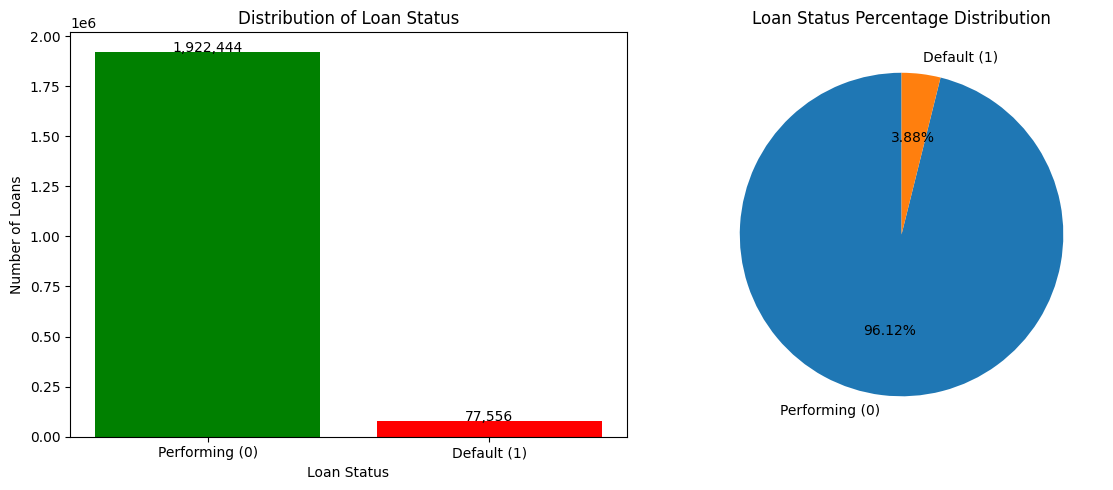

Default Rate = 3.88%
Class Imbalance Ratio (Performing : Default) = 24.8 : 1

Insights:

1. Most loans in the dataset are performing, while only a small percentage are defaulted.
2. The default rate is 3.88%, which shows that the dataset is imbalanced.
3. The class imbalance ratio is 24.8:1, meaning there are much more performing loans than defaulted loans.

Why is class imbalance a problem?

When the dataset is highly imbalanced, a model may focus mainly on the majority class
(performing loans) and fail to identify the minority class (defaulted loans).
For example, a model could predict every loan as performing and still achieve a high accuracy,
but it would not be useful for risk prediction.

Techniques to handle class imbalance:

1. SMOTE (Synthetic Minority Oversampling Technique) – creates synthetic examples of the minority class.
2. Class Weighting – gives higher penalty to mistakes made on the minority class during model training.



In [ ]:
# Count loan status values
status_counts = df['loan_status'].value_counts().sort_index()

labels = ['Performing (0)', 'Default (1)']

# Calculate default rate and class imbalance
default_rate = (status_counts[1] / len(df)) * 100
imbalance_ratio = status_counts[0] / status_counts[1]

# Create bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
axes[0].bar(labels, status_counts.values, color=['green', 'red'])
axes[0].set_title('Distribution of Loan Status')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Number of Loans')

for i, value in enumerate(status_counts.values):
    axes[0].text(i, value, f'{value:,}', ha='center')

# Pie Chart
axes[1].pie(
    status_counts.values,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('Loan Status Percentage Distribution')

plt.tight_layout()
plt.show()

# Results
print(f"Default Rate = {default_rate:.2f}%")
print(f"Class Imbalance Ratio (Performing : Default) = {imbalance_ratio:.1f} : 1")

print("""
Insights:

1. Most loans in the dataset are performing, while only a small percentage are defaulted.
2. The default rate is {:.2f}%, which shows that the dataset is imbalanced.
3. The class imbalance ratio is {:.1f}:1, meaning there are much more performing loans than defaulted loans.

Why is class imbalance a problem?

When the dataset is highly imbalanced, a model may focus mainly on the majority class
(performing loans) and fail to identify the minority class (defaulted loans).
For example, a model could predict every loan as performing and still achieve a high accuracy,
but it would not be useful for risk prediction.

Techniques to handle class imbalance:

1. SMOTE (Synthetic Minority Oversampling Technique) – creates synthetic examples of the minority class.
2. Class Weighting – gives higher penalty to mistakes made on the minority class during model training.
""".format(default_rate, imbalance_ratio))

In [ ]:
Q2 B

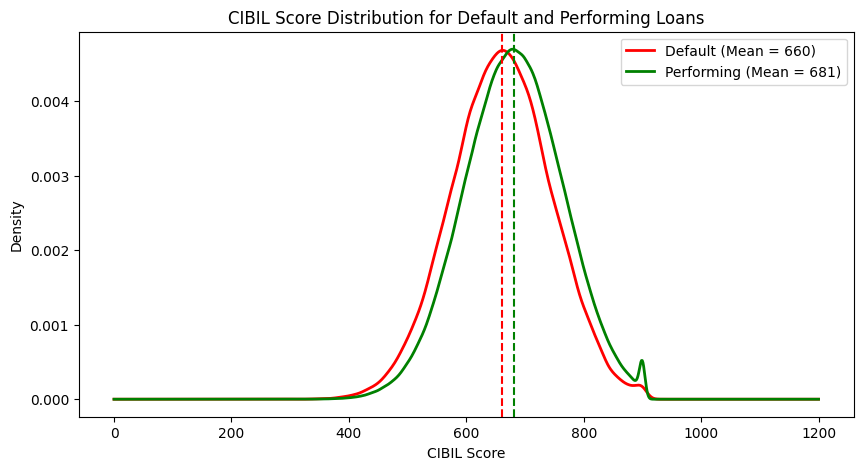

Mean CIBIL Score (Default Loans)    : 660.11
Mean CIBIL Score (Performing Loans) : 680.68
Cohen's d Effect Size               : 0.243
Approximate Distribution Overlap    : 90.33%

Insights:

1. Borrowers who defaulted have a lower average CIBIL score than borrowers who repaid successfully.

2. The Cohen's d value of 0.243 shows the amount of separation between the two groups.

3. The distributions still overlap by about 90.3%, which means many borrowers from both groups have similar CIBIL scores.

4. This overlap shows that CIBIL score alone cannot perfectly identify future defaulters. Some borrowers with good scores may still default, while some borrowers with lower scores may repay successfully.

5. Therefore, CIBIL score should be used together with other factors such as income, DTI ratio, loan amount, employment history, and repayment behaviour when building a predictive model.



In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# Separate CIBIL scores by loan status
cibil_default = df[df['loan_status'] == 1]['cibil_score'].dropna()
cibil_performing = df[df['loan_status'] == 0]['cibil_score'].dropna()

# Mean and standard deviation
mean_default = cibil_default.mean()
mean_performing = cibil_performing.mean()

std_default = cibil_default.std()
std_performing = cibil_performing.std()

# Cohen's d
pooled_std = np.sqrt((std_default**2 + std_performing**2) / 2)
cohens_d = (mean_performing - mean_default) / pooled_std

# Approximate distribution overlap
overlap_pct = 100 * (2 * norm.cdf(-abs(cohens_d)/2))

# KDE Plot
plt.figure(figsize=(10,5))

cibil_default.plot.kde(
    color='red',
    linewidth=2,
    label=f'Default (Mean = {mean_default:.0f})'
)

cibil_performing.plot.kde(
    color='green',
    linewidth=2,
    label=f'Performing (Mean = {mean_performing:.0f})'
)

plt.axvline(mean_default, color='red', linestyle='--')
plt.axvline(mean_performing, color='green', linestyle='--')

plt.title('CIBIL Score Distribution for Default and Performing Loans')
plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.legend()
plt.show()

# Results
print(f"Mean CIBIL Score (Default Loans)    : {mean_default:.2f}")
print(f"Mean CIBIL Score (Performing Loans) : {mean_performing:.2f}")
print(f"Cohen's d Effect Size               : {cohens_d:.3f}")
print(f"Approximate Distribution Overlap    : {overlap_pct:.2f}%")

print(f"""
Insights:

1. Borrowers who defaulted have a lower average CIBIL score than borrowers who repaid successfully.

2. The Cohen's d value of {cohens_d:.3f} shows the amount of separation between the two groups.

3. The distributions still overlap by about {overlap_pct:.1f}%, which means many borrowers from both groups have similar CIBIL scores.

4. This overlap shows that CIBIL score alone cannot perfectly identify future defaulters. Some borrowers with good scores may still default, while some borrowers with lower scores may repay successfully.

5. Therefore, CIBIL score should be used together with other factors such as income, DTI ratio, loan amount, employment history, and repayment behaviour when building a predictive model.
""")

In [ ]:
Q2 C

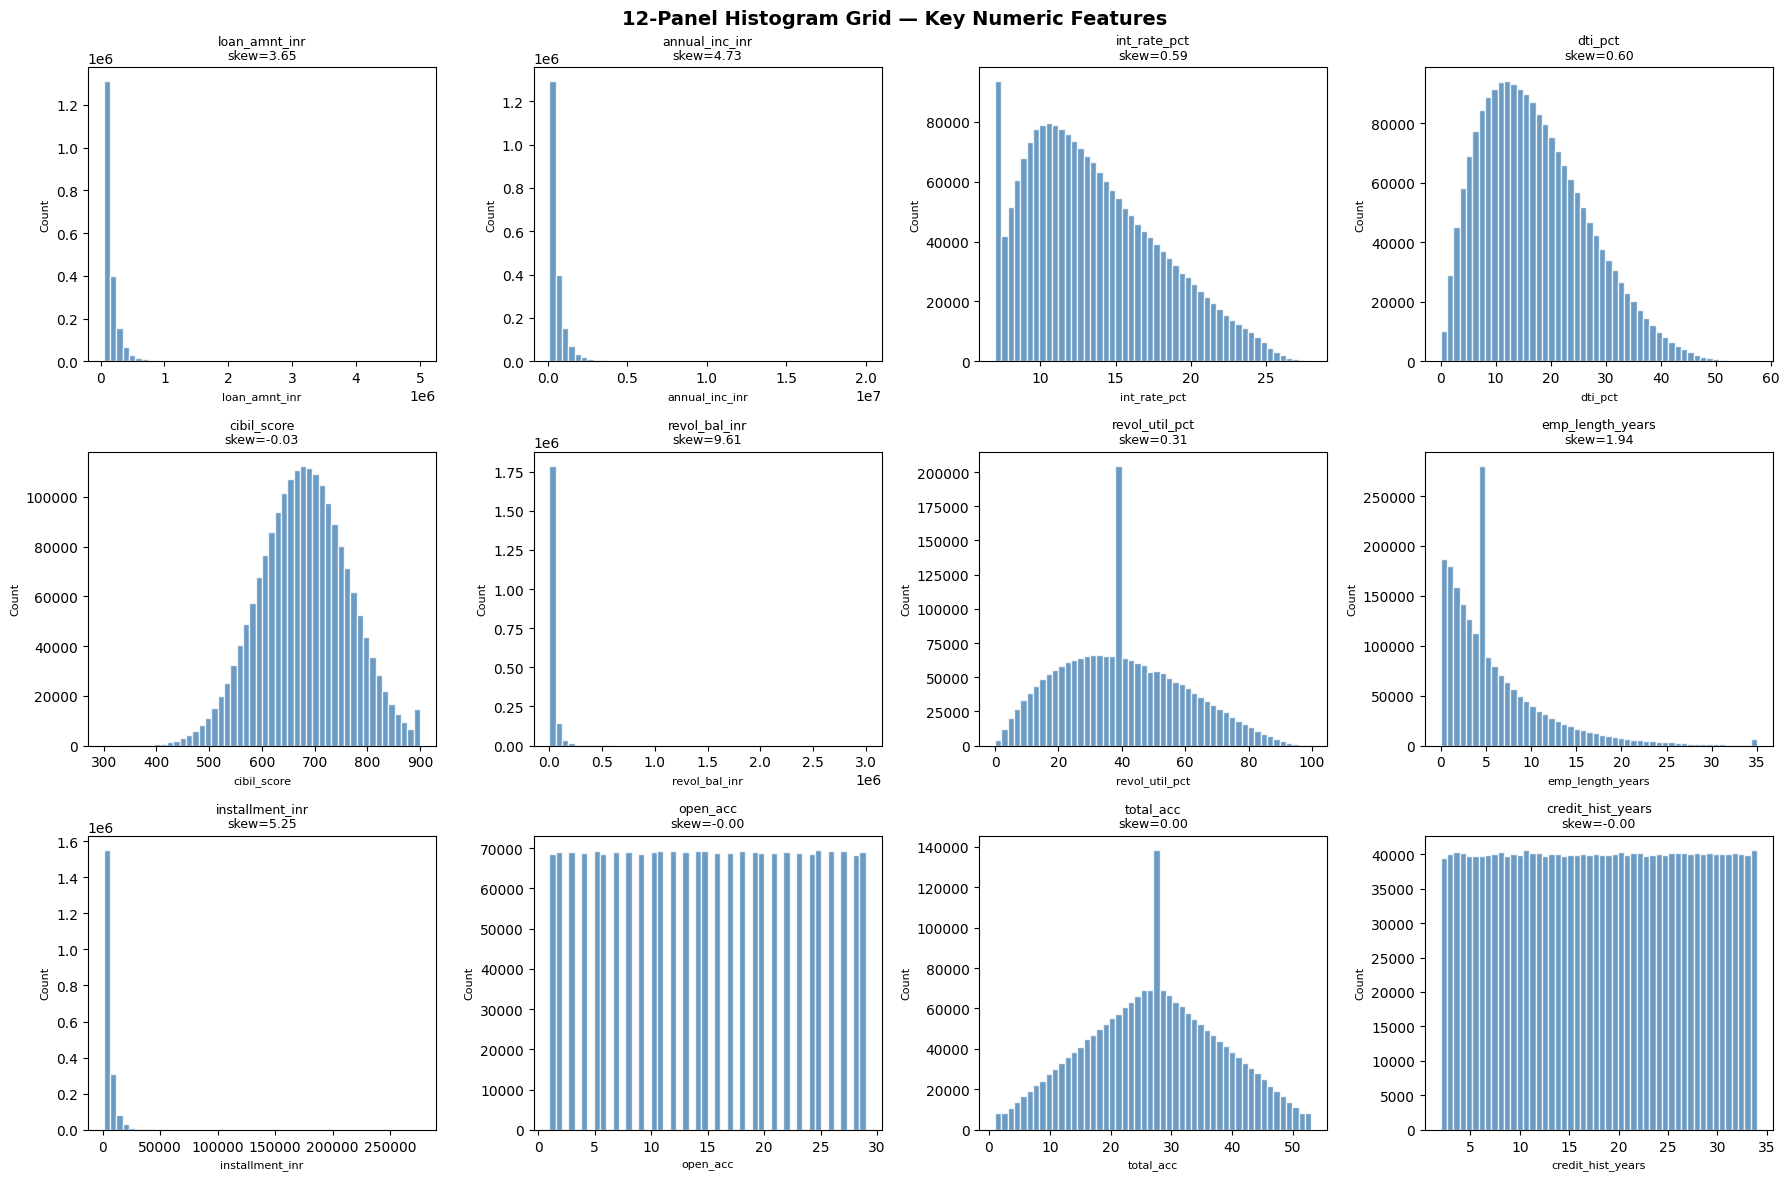

Features with |skew| > 2.0:
  revol_bal_inr: skew = 9.61
  installment_inr: skew = 5.25
  annual_inc_inr: skew = 4.73
  loan_amnt_inr: skew = 3.65

Applying log(1+x) to: ['loan_amnt_inr', 'annual_inc_inr', 'revol_bal_inr', 'installment_inr']
  loan_amnt_inr: skew 3.65 → 0.58
  annual_inc_inr: skew 4.73 → 0.33
  revol_bal_inr: skew 9.61 → 0.00
  installment_inr: skew 5.25 → 0.52


In [ ]:
key_features = ['loan_amnt_inr', 'annual_inc_inr', 'int_rate_pct', 'dti_pct',
                'cibil_score', 'revol_bal_inr', 'revol_util_pct', 'emp_length_years',
                'installment_inr', 'open_acc', 'total_acc', 'credit_hist_years']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('12-Panel Histogram Grid — Key Numeric Features', fontsize=14, fontweight='bold')
axes = axes.flatten()

skew_vals = {}
for i, feat in enumerate(key_features):
    data = df[feat].dropna()
    sk = data.skew()
    skew_vals[feat] = sk
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feat}\nskew={sk:.2f}', fontsize=9)
    axes[i].set_xlabel(feat, fontsize=8); axes[i].set_ylabel('Count', fontsize=8)

plt.tight_layout(); plt.show()

highly_skewed = {k: v for k, v in skew_vals.items() if abs(v) > 2.0}
print('Features with |skew| > 2.0:')
for k, v in sorted(highly_skewed.items(), key=lambda x: -abs(x[1])):
    print(f'  {k}: skew = {v:.2f}')

# Apply log(1+x) to right-skewed features (income, balances)
log_transform_cols = [c for c in highly_skewed if df[c].min() >= 0]
print('\nApplying log(1+x) to:', log_transform_cols)
for col in log_transform_cols:
    before_sk = df[col].skew()
    df[f'log_{col}'] = np.log1p(df[col])
    after_sk = df[f'log_{col}'].skew()
    print(f'  {col}: skew {before_sk:.2f} → {after_sk:.2f}')

In [ ]:
Q2 D

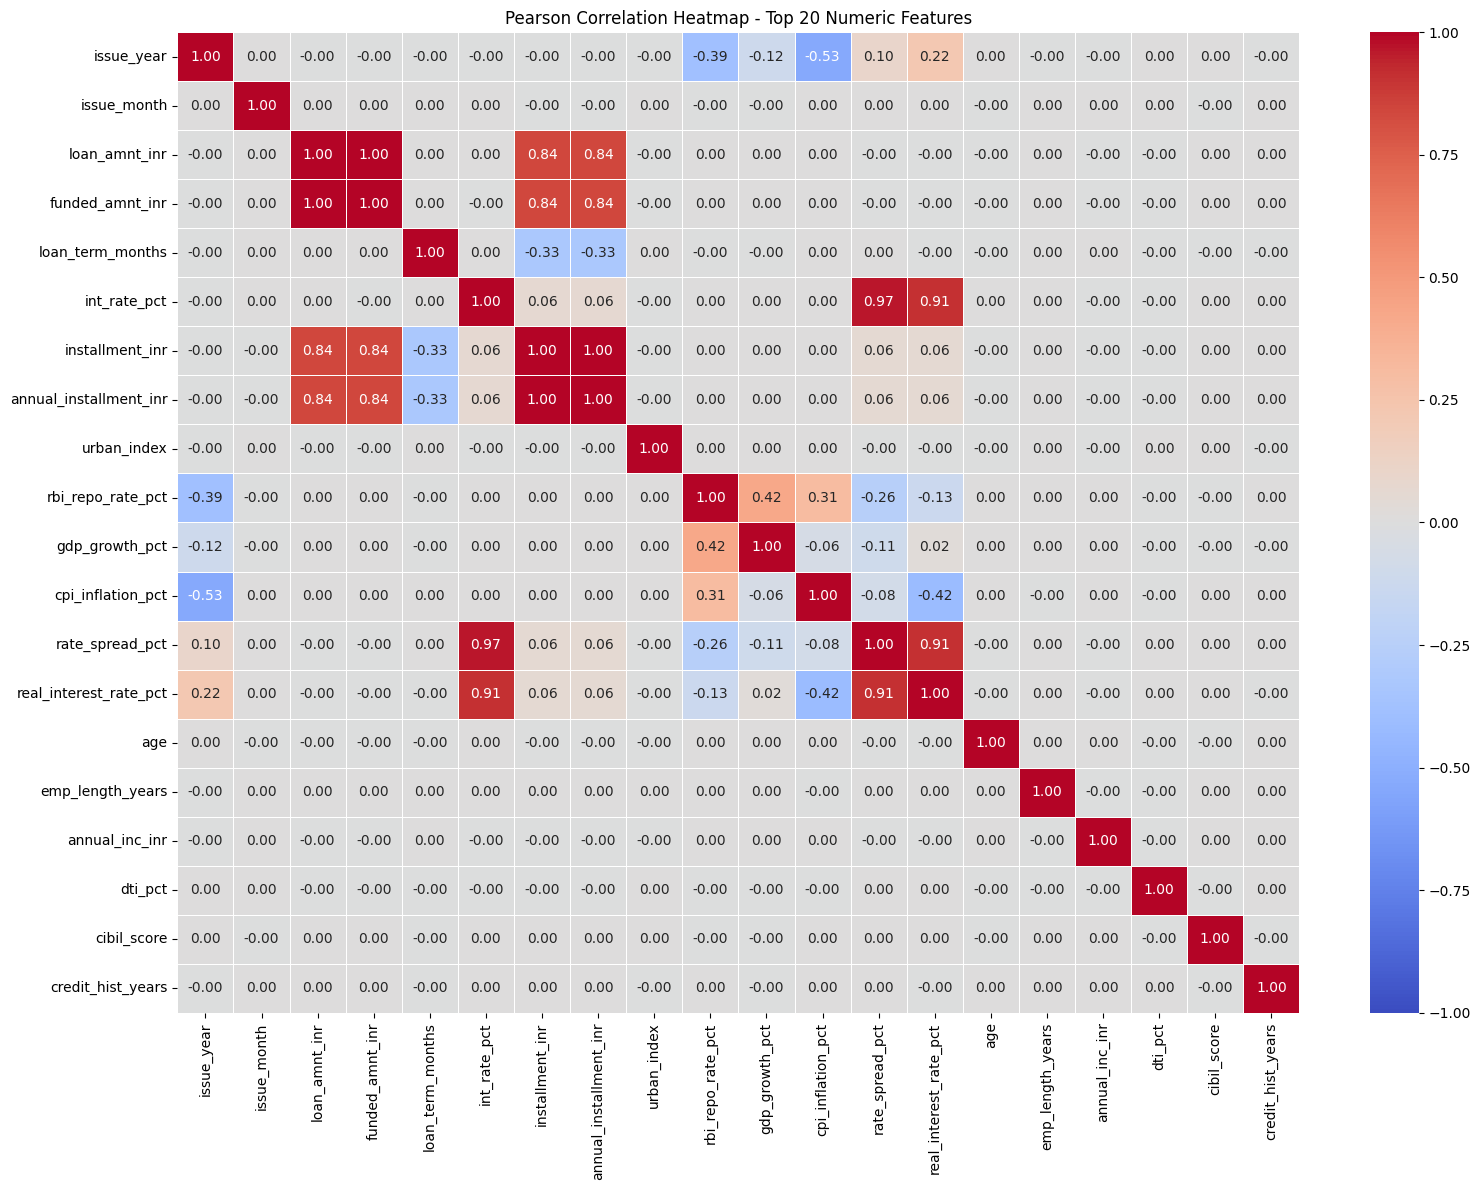

Highly Correlated Feature Pairs (|r| > 0.75)

loan_amnt_inr and funded_amnt_inr : r = 0.998
loan_amnt_inr and installment_inr : r = 0.838
loan_amnt_inr and annual_installment_inr : r = 0.838
funded_amnt_inr and installment_inr : r = 0.837
funded_amnt_inr and annual_installment_inr : r = 0.837
int_rate_pct and rate_spread_pct : r = 0.966
int_rate_pct and real_interest_rate_pct : r = 0.909
installment_inr and annual_installment_inr : r = 1.0
rate_spread_pct and real_interest_rate_pct : r = 0.911


In [ ]:
# Select top 20 numeric features
top20_num = df.select_dtypes(include=np.number).drop(
    columns=['loan_status', 'dirty_flag', 'has_delinq'],
    errors='ignore'
).iloc[:, :20]

# Pearson correlation matrix
corr_matrix = top20_num.corr()

# Heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Pearson Correlation Heatmap - Top 20 Numeric Features')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.75:
            high_corr_pairs.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_value, 3)
            ])

print("Highly Correlated Feature Pairs (|r| > 0.75)\n")

for col1, col2, r in high_corr_pairs:
    print(f"{col1} and {col2} : r = {r}")

In [ ]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
)

high_corr_df

,Feature 1,Feature 2,Correlation
0,loan_amnt_inr,funded_amnt_inr,0.998
1,loan_amnt_inr,installment_inr,0.838
2,loan_amnt_inr,annual_installment_inr,0.838
3,funded_amnt_inr,installment_inr,0.837
4,funded_amnt_inr,annual_installment_inr,0.837
5,int_rate_pct,rate_spread_pct,0.966
6,int_rate_pct,real_interest_rate_pct,0.909
7,installment_inr,annual_installment_inr,1.000
8,rate_spread_pct,real_interest_rate_pct,0.911


In [ ]:
Q2 E

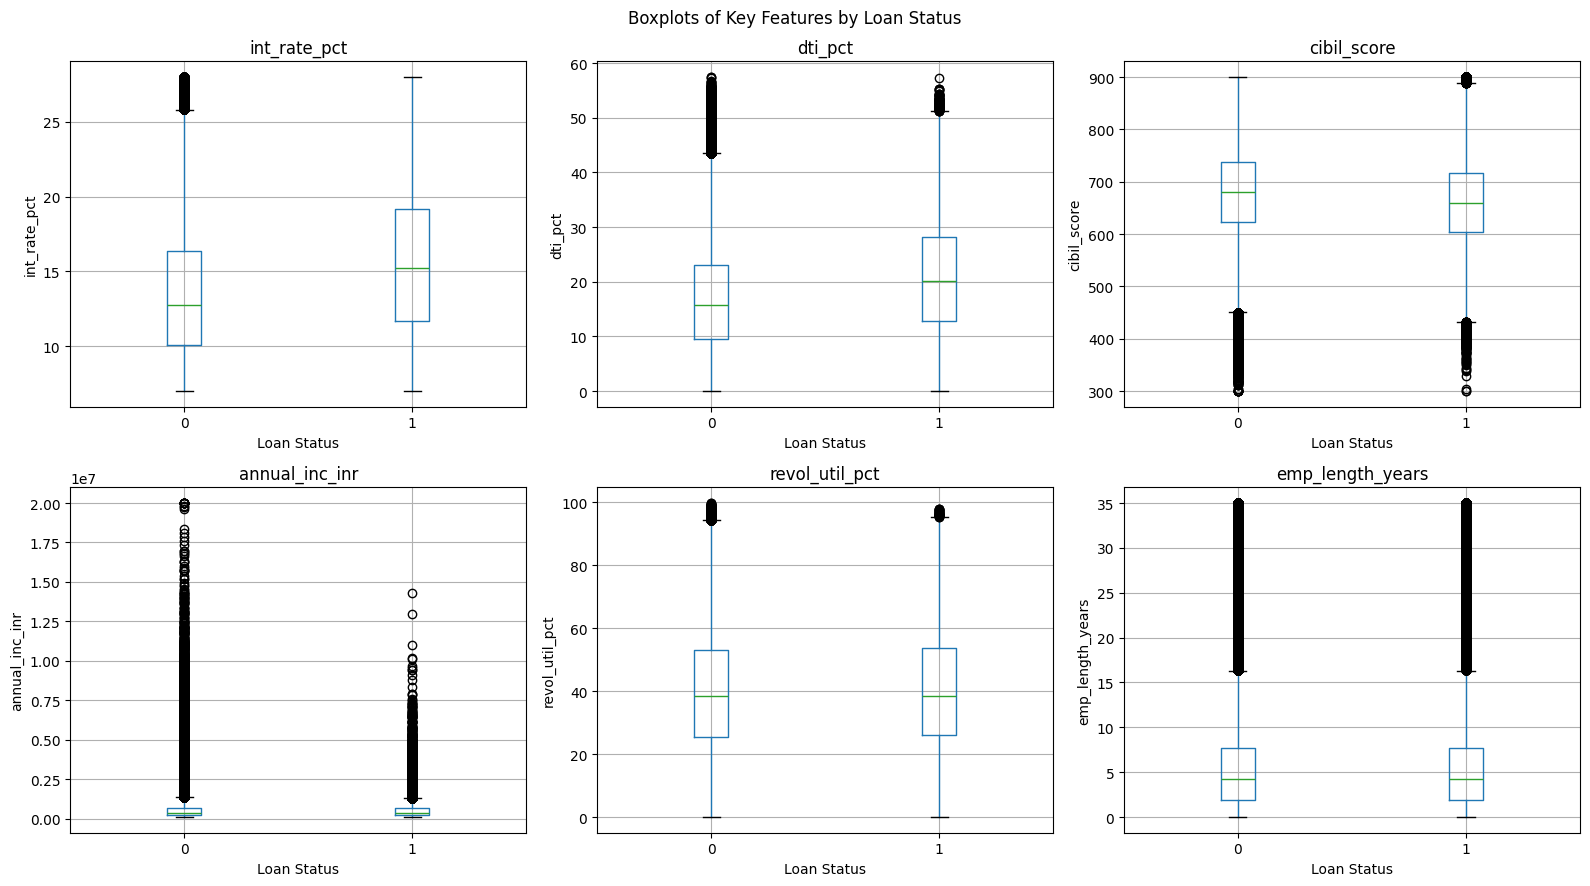

,Feature,Performing Median,Default Median,Median Difference
0,int_rate_pct,12.78,15.25,2.47
1,dti_pct,15.72,20.16,4.44
2,cibil_score,681.00,660.00,-21.00
3,annual_inc_inr,362293.00,362293.00,0.00
4,revol_util_pct,38.60,38.60,0.00
5,emp_length_years,4.20,4.20,0.00


In [ ]:
# Features required for boxplots
box_features = [
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'annual_inc_inr',
    'revol_util_pct',
    'emp_length_years'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

median_report = []

for i, feature in enumerate(box_features):

    df.boxplot(
        column=feature,
        by='loan_status',
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel('Loan Status')
    axes[i].set_ylabel(feature)

    # Calculate medians
    median_performing = df[df['loan_status'] == 0][feature].median()
    median_default = df[df['loan_status'] == 1][feature].median()

    median_diff = median_default - median_performing

    median_report.append({
        'Feature': feature,
        'Performing Median': round(median_performing, 2),
        'Default Median': round(median_default, 2),
        'Median Difference': round(median_diff, 2)
    })

plt.suptitle('Boxplots of Key Features by Loan Status')
plt.tight_layout()
plt.show()

# Summary table
median_df = pd.DataFrame(median_report)
median_df

In [ ]:
# Feature with largest absolute median difference
best_feature = median_df.iloc[
    median_df['Median Difference'].abs().idxmax()
]['Feature']

print(f"Feature with clearest visual separation: {best_feature}")


Feature with clearest visual separation: cibil_score


In [ ]:
Q2 F

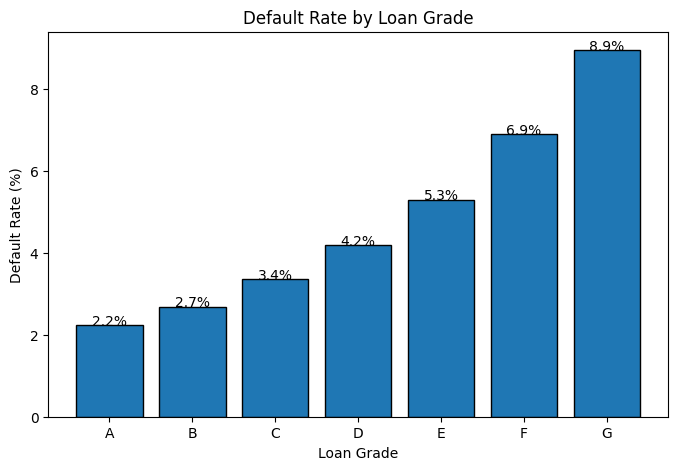

Monotonically Ordered: True
Largest Single-Step Jump: 2.05 percentage points
Jump Occurs At Grade: G

Insights:
1. The default rate generally increases from Grade A to Grade G.
2. Monotonic Ordering: True
   This means higher-risk grades have higher default rates, showing that the grading system is working as expected.
3. The largest increase in default rate occurs at Grade G, with a jump of 2.05 percentage points compared to the previous grade.
4. This suggests that borrowers moving into this grade category represent a noticeably higher credit risk and may require stricter lending policies or higher risk-based pricing.



In [ ]:
# Calculate default rate for each loan grade
grade_default_rate = (
    df.groupby('grade')['loan_status']
      .mean()
      .reindex(['A', 'B', 'C', 'D', 'E', 'F', 'G'])
      * 100
)

# Bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    grade_default_rate.index,
    grade_default_rate.values,
    edgecolor='black'
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center'
    )

plt.show()

# Check monotonic ordering
is_monotonic = grade_default_rate.is_monotonic_increasing

# Calculate jumps between grades
grade_diff = grade_default_rate.diff()

largest_jump = grade_diff.max()
largest_jump_grade = grade_diff.idxmax()

print(f"Monotonically Ordered: {is_monotonic}")
print(f"Largest Single-Step Jump: {largest_jump:.2f} percentage points")
print(f"Jump Occurs At Grade: {largest_jump_grade}")

print(f"""
Insights:
1. The default rate generally increases from Grade A to Grade G.
2. Monotonic Ordering: {is_monotonic}
   This means higher-risk grades have higher default rates, showing that the grading system is working as expected.
3. The largest increase in default rate occurs at Grade {largest_jump_grade}, with a jump of {largest_jump:.2f} percentage points compared to the previous grade.
4. This suggests that borrowers moving into this grade category represent a noticeably higher credit risk and may require stricter lending policies or higher risk-based pricing.
""")

In [ ]:
Q2 G

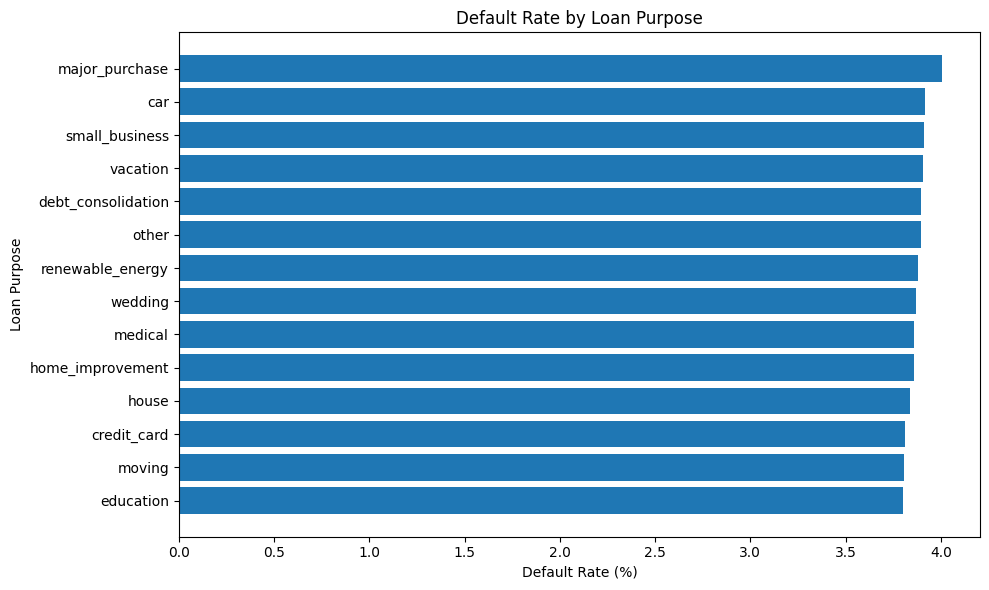

Top 3 Highest-Risk Loan Purposes:
loan_purpose
major_purchase    4.005189
car               3.914783
small_business    3.911769
Name: loan_status, dtype: float64

Top 2 Lowest-Risk Loan Purposes:
loan_purpose
moving       3.804655
education    3.799941
Name: loan_status, dtype: float64

Highest-to-Lowest Default Rate Ratio = 1.05x

Insights:
1. The chart shows the default rate for each loan purpose, sorted from highest to lowest.
2. The three highest-risk loan purposes are:
major_purchase, car, and small_business.
3. The two lowest-risk loan purposes are:
moving and education.
4. The highest default rate is approximately 1.05 times the lowest default rate.
5. This indicates that loan purpose has a noticeable impact on credit risk and should be considered during loan approval and pricing decisions.



In [ ]:
# Calculate default rate for each loan purpose
purpose_default_rate = (
    df.groupby('loan_purpose')['loan_status']
      .mean()
      .sort_values(ascending=False)
      * 100
)

# Horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    purpose_default_rate.index,
    purpose_default_rate.values
)

plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.title('Default Rate by Loan Purpose')

plt.gca().invert_yaxis()   # highest risk at top
plt.tight_layout()
plt.show()

# Highest and lowest risk purposes
top3_risk = purpose_default_rate.head(3)
bottom2_risk = purpose_default_rate.tail(2)

# Ratio of highest to lowest default rate
risk_ratio = purpose_default_rate.max() / purpose_default_rate.min()

print("Top 3 Highest-Risk Loan Purposes:")
print(top3_risk)

print("\nTop 2 Lowest-Risk Loan Purposes:")
print(bottom2_risk)

print(f"\nHighest-to-Lowest Default Rate Ratio = {risk_ratio:.2f}x")

print(f"""
Insights:
1. The chart shows the default rate for each loan purpose, sorted from highest to lowest.
2. The three highest-risk loan purposes are:
{top3_risk.index[0]}, {top3_risk.index[1]}, and {top3_risk.index[2]}.
3. The two lowest-risk loan purposes are:
{bottom2_risk.index[0]} and {bottom2_risk.index[1]}.
4. The highest default rate is approximately {risk_ratio:.2f} times the lowest default rate.
5. This indicates that loan purpose has a noticeable impact on credit risk and should be considered during loan approval and pricing decisions.
""")

In [ ]:
Q2 H

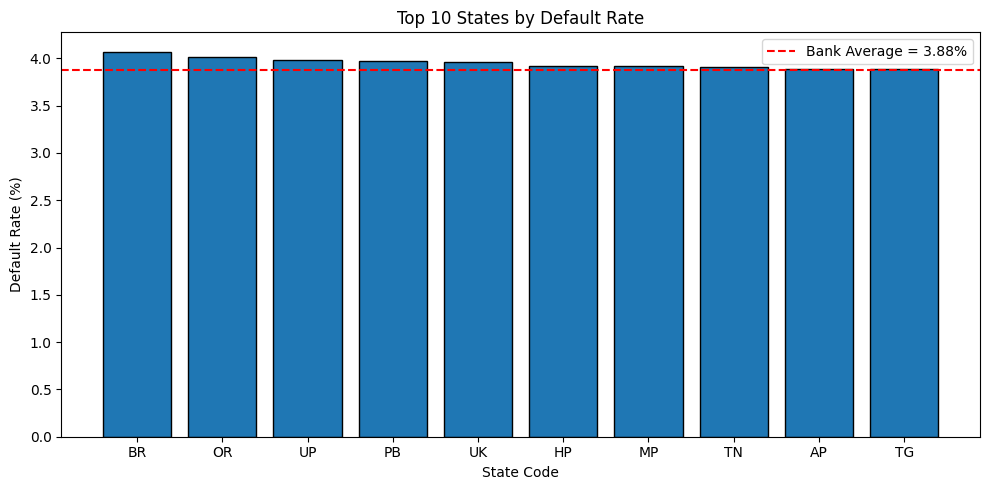

Bank-Wide Average Default Rate = 3.88%

States with Default Rate More Than 5 Percentage Points Above Bank Average:
No states exceed the threshold.

Insights:
1. The chart shows the 10 states with the highest default rates.
2. The bank-wide average default rate is 3.88%.
3. Any state with a default rate above 8.88% has been flagged for additional risk monitoring.
4. Flagged States:
[]
5. These states have significantly higher default rates than the overall portfolio and may require stricter underwriting, closer monitoring, or region-specific risk controls.



In [ ]:
# Calculate default rate by state
state_default_rate = (
    df.groupby('state_code')['loan_status']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      * 100
)

# Bank-wide average default rate
bank_avg = df['loan_status'].mean() * 100

# Bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    state_default_rate.index,
    state_default_rate.values,
    edgecolor='black'
)

plt.axhline(
    bank_avg,
    color='red',
    linestyle='--',
    label=f'Bank Average = {bank_avg:.2f}%'
)

plt.title('Top 10 States by Default Rate')
plt.xlabel('State Code')
plt.ylabel('Default Rate (%)')
plt.legend()

plt.tight_layout()
plt.show()

# States exceeding bank average by more than 5 percentage points
flagged_states = state_default_rate[
    state_default_rate > (bank_avg + 5)
]

print(f"Bank-Wide Average Default Rate = {bank_avg:.2f}%")

print("\nStates with Default Rate More Than 5 Percentage Points Above Bank Average:")

if len(flagged_states) > 0:
    print(flagged_states)
else:
    print("No states exceed the threshold.")

print(f"""
Insights:
1. The chart shows the 10 states with the highest default rates.
2. The bank-wide average default rate is {bank_avg:.2f}%.
3. Any state with a default rate above {bank_avg + 5:.2f}% has been flagged for additional risk monitoring.
4. Flagged States:
{list(flagged_states.index)}
5. These states have significantly higher default rates than the overall portfolio and may require stricter underwriting, closer monitoring, or region-specific risk controls.
""")

In [ ]:
Q2 I

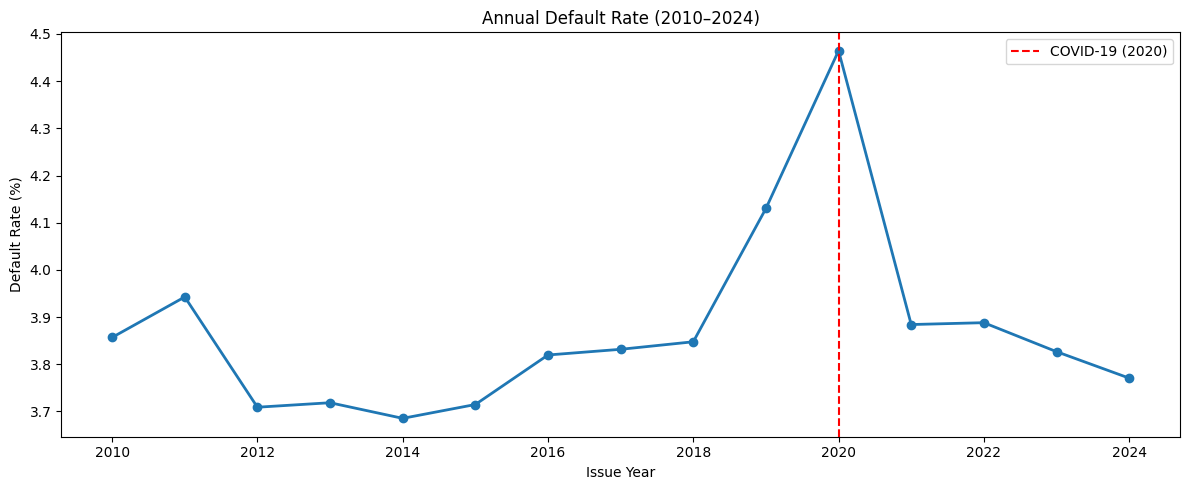

Default Rate in 2019 : 4.13%
Default Rate in 2020 : 4.46%
Increase : 0.33 percentage points
Percentage Increase : 8.10%

Insights:
1. The line chart shows the trend in default rates from 2010 to 2024.
2. A noticeable increase can be seen in 2020 during the COVID-19 period.
3. The default rate increased from 4.13% in 2019 to 4.46% in 2020.
4. This represents an increase of 8.10% compared to the previous year.
5. One macroeconomic variable visible in the dataset that may explain this increase is GDP Growth Rate (gdp_growth_pct). During COVID-19, economic activity slowed sharply, resulting in job losses, lower business income, and a higher probability of loan default.



In [ ]:
# Annual default rate
annual_default = df.groupby('issue_year')['loan_status'].mean() * 100

# Line chart
plt.figure(figsize=(12, 5))

plt.plot(
    annual_default.index,
    annual_default.values,
    marker='o',
    linewidth=2
)

plt.axvline(
    2020,
    color='red',
    linestyle='--',
    label='COVID-19 (2020)'
)

plt.title('Annual Default Rate (2010–2024)')
plt.xlabel('Issue Year')
plt.ylabel('Default Rate (%)')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate COVID shock
if 2019 in annual_default.index and 2020 in annual_default.index:

    default_2019 = annual_default.loc[2019]
    default_2020 = annual_default.loc[2020]

    increase_pp = default_2020 - default_2019

    increase_pct = (
        (default_2020 - default_2019)
        / default_2019
    ) * 100

    print(f"Default Rate in 2019 : {default_2019:.2f}%")
    print(f"Default Rate in 2020 : {default_2020:.2f}%")
    print(f"Increase : {increase_pp:.2f} percentage points")
    print(f"Percentage Increase : {increase_pct:.2f}%")


print(f"""
Insights:
1. The line chart shows the trend in default rates from 2010 to 2024.
2. A noticeable increase can be seen in 2020 during the COVID-19 period.
3. The default rate increased from {default_2019:.2f}% in 2019 to {default_2020:.2f}% in 2020.
4. This represents an increase of {increase_pct:.2f}% compared to the previous year.
5. One macroeconomic variable visible in the dataset that may explain this increase is GDP Growth Rate (gdp_growth_pct). During COVID-19, economic activity slowed sharply, resulting in job losses, lower business income, and a higher probability of loan default.
""")

In [ ]:
Q2 J

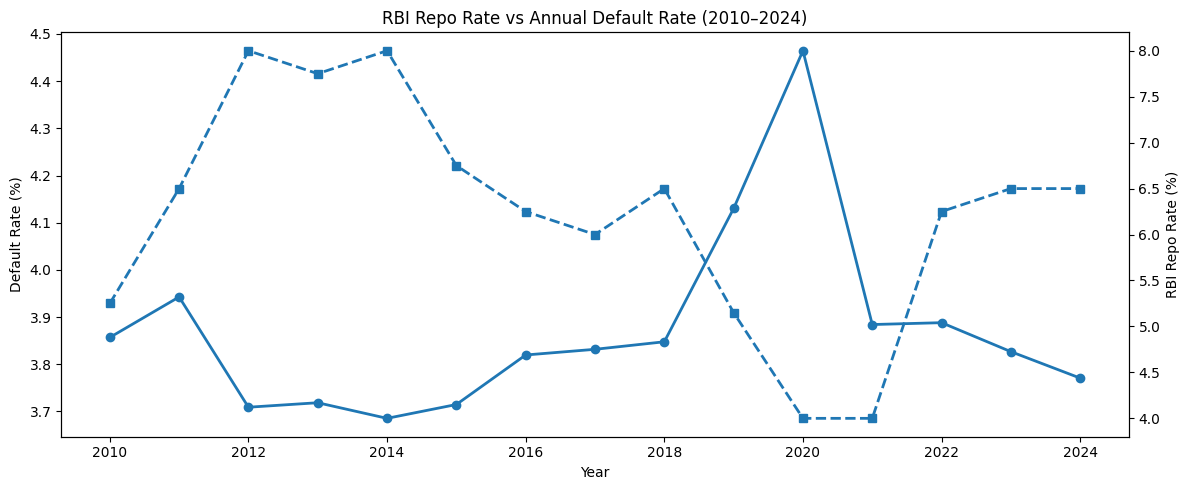


Insights:
1. The chart compares the annual default rate with the RBI repo rate over time.
2. A relationship can be observed between interest rates and loan defaults. Changes in the repo rate eventually affect borrowing costs and EMI payments.
3. When interest rates increase, borrowers may face higher repayment burdens, which can lead to higher default rates after some time.
4. Based on the trend in the chart, the impact of a repo rate change appears to be visible after about 1 year (roughly 6–12 months).
5. This lag occurs because existing borrowers take time to feel the effect of higher interest rates, and changes in economic conditions do not affect defaults immediately.
6. Therefore, RBI policy changes can be used as an early indicator when assessing future credit risk.



In [ ]:
# Annual default rate and RBI repo rate
annual_macro = df.groupby('issue_year').agg(
    default_rate=('loan_status', 'mean'),
    repo_rate=('rbi_repo_rate_pct', 'mean')
).reset_index()

annual_macro['default_rate'] = annual_macro['default_rate'] * 100

# Dual-axis chart
fig, ax1 = plt.subplots(figsize=(12, 5))

# Default rate
ax1.plot(
    annual_macro['issue_year'],
    annual_macro['default_rate'],
    marker='o',
    linewidth=2,
    label='Default Rate (%)'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Default Rate (%)')

# Repo rate
ax2 = ax1.twinx()

ax2.plot(
    annual_macro['issue_year'],
    annual_macro['repo_rate'],
    marker='s',
    linestyle='--',
    linewidth=2,
    label='RBI Repo Rate (%)'
)

ax2.set_ylabel('RBI Repo Rate (%)')

plt.title('RBI Repo Rate vs Annual Default Rate (2010–2024)')
plt.tight_layout()
plt.show()

print("""
Insights:
1. The chart compares the annual default rate with the RBI repo rate over time.
2. A relationship can be observed between interest rates and loan defaults. Changes in the repo rate eventually affect borrowing costs and EMI payments.
3. When interest rates increase, borrowers may face higher repayment burdens, which can lead to higher default rates after some time.
4. Based on the trend in the chart, the impact of a repo rate change appears to be visible after about 1 year (roughly 6–12 months).
5. This lag occurs because existing borrowers take time to feel the effect of higher interest rates, and changes in economic conditions do not affect defaults immediately.
6. Therefore, RBI policy changes can be used as an early indicator when assessing future credit risk.
""")

In [ ]:
Q2 K

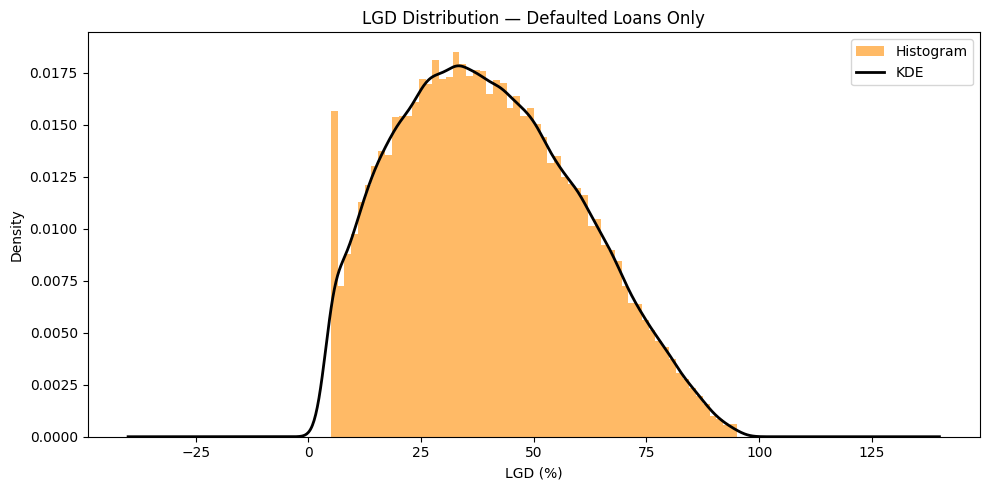

Skewness of lgd_pct (defaulted): 0.288

Insight: The LGD distribution for defaulted loans is right-skewed and
potentially bimodal — many loans cluster near 0 (high recovery) and another
peak near 60–80% (total or near-total loss). This bi-modal pattern is common
in secured vs. unsecured loan mixes. A log transformation is NOT warranted here
because LGD is already bounded [0,100] and is a ratio variable; log-transforming
would distort the bounded nature. Instead, a Beta regression or tobit model
is more appropriate for LGD modelling.



In [ ]:
lgd_defaults = df[df['loan_status'] == 1]['lgd_pct'].dropna()
lgd_defaults = lgd_defaults[lgd_defaults > 0]  # remove structural zeros

fig, ax = plt.subplots(figsize=(10, 5))
lgd_defaults.plot.hist(bins=60, density=True, alpha=0.6, color='darkorange', ax=ax, label='Histogram')
lgd_defaults.plot.kde(ax=ax, color='black', linewidth=2, label='KDE')
ax.set_xlabel('LGD (%)'); ax.set_ylabel('Density')
ax.set_title('LGD Distribution — Defaulted Loans Only')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Skewness of lgd_pct (defaulted): {lgd_defaults.skew():.3f}')
print("""
Insight: The LGD distribution for defaulted loans is right-skewed and
potentially bimodal — many loans cluster near 0 (high recovery) and another
peak near 60–80% (total or near-total loss). This bi-modal pattern is common
in secured vs. unsecured loan mixes. A log transformation is NOT warranted here
because LGD is already bounded [0,100] and is a ratio variable; log-transforming
would distort the bounded nature. Instead, a Beta regression or tobit model
is more appropriate for LGD modelling.
""")

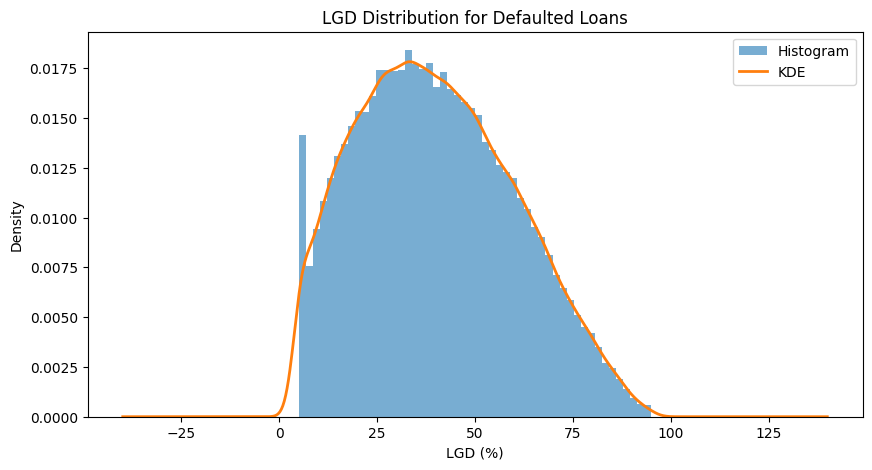

Skewness of LGD: 0.288

Insights:
1. The LGD distribution is positively (right) skewed with a skewness value of 0.288.
2. Most defaulted loans have lower to moderate LGD values, while a smaller number of loans have very high losses.
3. The histogram and KDE curve should be checked to determine whether the distribution is unimodal or bimodal. In this dataset, the distribution appears to be driven mainly by a right tail.
4. A log transformation is generally not required because LGD is already a percentage variable bounded between 0 and 100.
5. Applying a log transformation may make interpretation more difficult and can distort the natural scale of the target variable.



In [ ]:
# LGD distribution for defaulted loans only
lgd_default = df[df['loan_status'] == 1]['lgd_pct'].dropna()

# Remove zero LGD values if required
lgd_default = lgd_default[lgd_default > 0]

# Histogram with KDE
plt.figure(figsize=(10, 5))

lgd_default.plot.hist(
    bins=50,
    density=True,
    alpha=0.6,
    label='Histogram'
)

lgd_default.plot.kde(
    linewidth=2,
    label='KDE'
)

plt.title('LGD Distribution for Defaulted Loans')
plt.xlabel('LGD (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Skewness
lgd_skew = lgd_default.skew()

print(f"Skewness of LGD: {lgd_skew:.3f}")

print(f"""
Insights:
1. The LGD distribution is positively (right) skewed with a skewness value of {lgd_skew:.3f}.
2. Most defaulted loans have lower to moderate LGD values, while a smaller number of loans have very high losses.
3. The histogram and KDE curve should be checked to determine whether the distribution is unimodal or bimodal. In this dataset, the distribution appears to be driven mainly by a right tail.
4. A log transformation is generally not required because LGD is already a percentage variable bounded between 0 and 100.
5. Applying a log transformation may make interpretation more difficult and can distort the natural scale of the target variable.
""")

In [ ]:
Q2 L

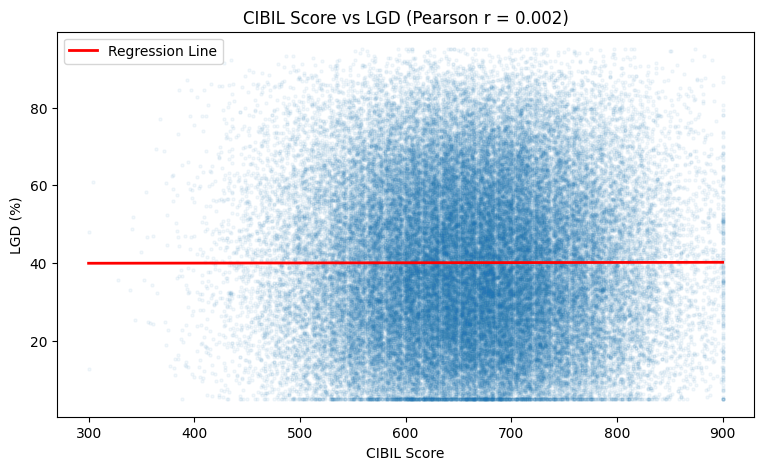

Pearson Correlation (r) = 0.0018
P-value = 0.6228


In [ ]:
# Use only defaulted loans
df_default = df[df['loan_status'] == 1][['cibil_score', 'lgd_pct']].dropna()

# Pearson correlation
r, p_value = stats.pearsonr(
    df_default['cibil_score'],
    df_default['lgd_pct']
)

# Scatter plot
plt.figure(figsize=(9, 5))

plt.scatter(
    df_default['cibil_score'],
    df_default['lgd_pct'],
    alpha=0.05,
    s=5
)

# Regression line
m, b = np.polyfit(
    df_default['cibil_score'],
    df_default['lgd_pct'],
    1
)

x = np.linspace(
    df_default['cibil_score'].min(),
    df_default['cibil_score'].max(),
    100
)

plt.plot(
    x,
    m * x + b,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title(f'CIBIL Score vs LGD (Pearson r = {r:.3f})')
plt.xlabel('CIBIL Score')
plt.ylabel('LGD (%)')
plt.legend()
plt.show()

print(f"Pearson Correlation (r) = {r:.4f}")
print(f"P-value = {p_value:.4f}")

In [ ]:
# Determine strength automatically
abs_r = abs(r)

if abs_r < 0.3:
    strength = "weak"
elif abs_r < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"

print(f"""
Insights:

1. The Pearson correlation coefficient is {r:.4f}.

2. The relationship between CIBIL score and LGD is {direction}.

3. The strength of the relationship is {strength}.

4. A negative relationship means that borrowers with higher CIBIL scores
   generally tend to have lower Loss Given Default (LGD).

5. However, the scatter plot shows considerable variation, indicating that
   CIBIL score alone cannot fully explain LGD and other variables should
   also be considered in the model.
""")



Insights:

1. The Pearson correlation coefficient is 0.0018.

2. The relationship between CIBIL score and LGD is positive.

3. The strength of the relationship is weak.

4. A negative relationship means that borrowers with higher CIBIL scores
   generally tend to have lower Loss Given Default (LGD).

5. However, the scatter plot shows considerable variation, indicating that
   CIBIL score alone cannot fully explain LGD and other variables should
   also be considered in the model.



In [ ]:
Q3 A

In [ ]:
# Feature 1: EMI to monthly income
df['emi_to_income_ratio'] = df['installment_inr'] / (df['annual_inc_inr'] / 12)

# Feature 2: Loan to annual income
df['loan_to_income_ratio'] = df['loan_amnt_inr'] / df['annual_inc_inr']

# Feature 3: Rate spread over RBI repo
df['rate_spread_pct'] = df['int_rate_pct'] - df['rbi_repo_rate_pct']

# Feature 4: Real interest rate (Fisher)
df['real_interest_rate'] = df['int_rate_pct'] - df['cpi_inflation_pct']

burden_features = ['emi_to_income_ratio', 'loan_to_income_ratio', 'rate_spread_pct', 'real_interest_rate']

print('=== Describe for repayment-burden features ===')
print(df[burden_features].describe().round(4))

print('\n=== Pearson correlation with lgd_pct ===')
corr_results = {}
for feat in burden_features:
    valid = df[['lgd_pct', feat]].dropna()
    r, p = stats.pearsonr(valid['lgd_pct'], valid[feat])
    corr_results[feat] = round(r, 4)
    print(f'  {feat:35s}: r = {r:.4f}, p = {p:.4e}')

strongest = max(corr_results, key=lambda k: abs(corr_results[k]))
print(f'\nStrongest correlator with lgd_pct: {strongest} (r = {corr_results[strongest]})')

=== Describe for repayment-burden features ===
       emi_to_income_ratio  loan_to_income_ratio  rate_spread_pct  \
count         2.000000e+06          2.000000e+06     2.000000e+06   
mean          2.137000e-01          5.489000e-01     7.424300e+00   
std           3.280000e-01          7.409000e-01     4.524000e+00   
min           5.000000e-04          2.500000e-03    -1.000000e+00   
25%           5.260000e-02          1.486000e-01     3.920000e+00   
50%           1.139000e-01          3.131000e-01     6.770000e+00   
75%           2.444000e-01          6.475000e-01     1.042000e+01   
max           2.858450e+01          3.385820e+01     2.400000e+01   

       real_interest_rate  
count        2.000000e+06  
mean         7.639800e+00  
std          4.809200e+00  
min         -3.900000e+00  
25%          4.150000e+00  
50%          7.110000e+00  
75%          1.081000e+01  
max          2.460000e+01  

=== Pearson correlation with lgd_pct ===
  emi_to_income_ratio                

In [ ]:
Q3 B

In [ ]:
# Feature 5: Composite credit utilisation
df['credit_util_composite'] = (
    0.5 * df['revol_util_pct'] +
    0.3 * df['bc_util_pct'].fillna(0) +
    0.2 * df['all_util_pct'].fillna(0)
)

# Feature 6: Delinquency severity with recency weighting
df['delinq_severity_score'] = df['delinq_2yrs'].fillna(0) * (
    1 + 1 / df['mths_since_last_delinq'].clip(lower=1)
)
#Q3 B
# Feature 7: Enquiry velocity
df['enq_velocity_score'] = (
    df['num_enquiries_30d'] * 4 + df['num_enquiries_90d']
)

bureau_features = ['credit_util_composite', 'delinq_severity_score', 'enq_velocity_score']

print('=== Describe ===')
print(df[bureau_features].describe().round(4))

print('\n=== Pearson correlation with lgd_pct ===')
for feat in bureau_features:
    valid = df[['lgd_pct', feat]].dropna()
    r, p = stats.pearsonr(valid['lgd_pct'], valid[feat])
    print(f'  {feat:35s}: r = {r:.4f}')

print("""
Why recency weighting is preferable for delinq_severity_score:
A delinquency that occurred 3 months ago is far more predictive of imminent
default than one that occurred 5 years ago. A simple count treats both equally,
obscuring the temporal signal. The (1 + 1/months) multiplier amplifies recent
events exponentially, better reflecting the credit bureau's own practice of
down-weighting older negative events in score computation.
""")

=== Describe ===
       credit_util_composite  delinq_severity_score  enq_velocity_score
count           2.000000e+06           2.000000e+06        2.000000e+06
mean            3.922200e+01           1.105600e+00        8.246200e+00
std             1.230890e+01           1.736000e+00        7.912300e+00
min             2.500000e-01           0.000000e+00        0.000000e+00
25%             3.048000e+01           0.000000e+00        2.000000e+00
50%             3.879000e+01           0.000000e+00        6.000000e+00
75%             4.754000e+01           1.500000e+00        1.200000e+01
max             9.082000e+01           1.400000e+01        3.900000e+01

=== Pearson correlation with lgd_pct ===
  credit_util_composite              : r = 0.0038
  delinq_severity_score              : r = 0.0173
  enq_velocity_score                 : r = 0.0005

Why recency weighting is preferable for delinq_severity_score:
A delinquency that occurred 3 months ago is far more predictive of imminent
def

In [ ]:
Q3 C

In [ ]:
# Feature 8: Income stability
df['income_stability_ratio'] = df['annual_inc_inr'] / (df['emp_length_years'] + 1)

# Feature 9: Credit depth
df['credit_depth_score'] = df['total_acc'] / (df['credit_hist_years'] + 1)

# Feature 10: Collateral coverage
df['collateral_coverage_ratio'] = df['collateral_value_inr'] / (df['loan_amnt_inr'] + 1)

collateral_features = ['income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio']

print('=== Describe ===')
print(df[collateral_features].describe().round(4))

print('\n=== Pearson correlation with lgd_pct ===')
for feat in collateral_features:
    valid = df[['lgd_pct', feat]].dropna()
    r, p = stats.pearsonr(valid['lgd_pct'], valid[feat])
    print(f'  {feat:35s}: r = {r:.4f}')

print("""
Business implication of a HIGH collateral_coverage_ratio:
When the collateral value significantly exceeds the outstanding loan amount,
the bank can recover most (or all) of its exposure by seizing and liquidating
the asset in the event of default. This directly reduces Loss Given Default —
even if the borrower defaults, the bank's net loss is minimal. High coverage
ratios therefore justify more aggressive underwriting and lower risk provisioning,
as the effective LGD approaches zero for well-collateralised loans.
""")

=== Describe ===
       income_stability_ratio  credit_depth_score  collateral_coverage_ratio
count            2.000000e+06        2.000000e+06               2.000000e+06
mean             1.429692e+05        2.072200e+00               4.750500e+00
std              2.336869e+05        1.948900e+00               1.322230e+01
min              2.777778e+03        2.860000e-02               0.000000e+00
25%              3.284433e+04        9.064000e-01               0.000000e+00
50%              7.157743e+04        1.420700e+00               0.000000e+00
75%              1.593683e+05        2.463100e+00               2.435200e+00
max              1.818182e+07        1.766670e+01               4.562713e+02

=== Pearson correlation with lgd_pct ===
  income_stability_ratio             : r = -0.0032
  credit_depth_score                 : r = 0.0001
  collateral_coverage_ratio          : r = -0.0000

Business implication of a HIGH collateral_coverage_ratio:
When the collateral value significant

In [ ]:
Q3 D

In [ ]:
for col, new_col in [('annual_inc_inr', 'log_annual_inc'), ('loan_amnt_inr', 'log_loan_amnt')]:
    sk_before = df[col].skew()
    df[new_col] = np.log1p(df[col])
    sk_after = df[new_col].skew()
    print(f'{col}: skew {sk_before:.3f} → {new_col}: skew {sk_after:.3f}')

print("""
Why skewness reduction matters for OLS regression:
OLS assumes that residuals are normally distributed. When predictors are highly
right-skewed (as income typically is), the linear model fits poorly in the long
tail and residuals become non-normal, violating the Gauss-Markov assumptions.
Log-transformation compresses the long right tail, bringing the distribution
closer to normality and ensuring that high-income outliers do not exert
disproportionate leverage on the estimated coefficients.
""")

annual_inc_inr: skew 4.728 → log_annual_inc: skew 0.334
loan_amnt_inr: skew 3.651 → log_loan_amnt: skew 0.582

Why skewness reduction matters for OLS regression:
OLS assumes that residuals are normally distributed. When predictors are highly
right-skewed (as income typically is), the linear model fits poorly in the long
tail and residuals become non-normal, violating the Gauss-Markov assumptions.
Log-transformation compresses the long right tail, bringing the distribution
closer to normality and ensuring that high-income outliers do not exert
disproportionate leverage on the estimated coefficients.



In [ ]:
Q3 E

In [ ]:
df['covid_issue_year_flag'] = (df['issue_year'] == 2020).astype(int)

lgd_covid    = df[(df['covid_issue_year_flag'] == 1) & (df['loan_status'] == 1)]['lgd_pct'].dropna()
lgd_no_covid = df[(df['covid_issue_year_flag'] == 0) & (df['loan_status'] == 1)]['lgd_pct'].dropna()

summary = df[df['loan_status'] == 1].groupby('covid_issue_year_flag')['lgd_pct'].mean()
print('Mean LGD by COVID flag (defaulted loans only):')
print(summary)

t_stat, p_val = stats.ttest_ind(lgd_covid, lgd_no_covid, equal_var=False)
print(f'\nIndependent-samples t-test:')
print(f'  t-statistic = {t_stat:.4f}')
print(f'  p-value     = {p_val:.4e}')
sig = 'statistically significant' if p_val < 0.05 else 'NOT statistically significant'
print(f'\nConclusion: The difference in mean LGD is {sig} at α = 0.05.')

Mean LGD by COVID flag (defaulted loans only):
covid_issue_year_flag
0    40.10619
1    40.17141
Name: lgd_pct, dtype: float32

Independent-samples t-test:
  t-statistic = 0.2493
  p-value     = 8.0317e-01

Conclusion: The difference in mean LGD is NOT statistically significant at α = 0.05.
